## **CIFAR-10**

In [2]:
print(f"Per class samples: {60000//10}")

Per class samples: 6000


## **CIFAR-100**

In [3]:
print(f"Per class samples: {60000//100}")

Per class samples: 600


In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("darkgrid")
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [5]:
import tensorflow as tf
from tensorflow import keras

In [6]:
random_state = 42

In [7]:
tf.keras.backend.clear_session()
np.random.seed(random_state)
tf.random.set_seed(random_state)

In [8]:
from keras.datasets import cifar10

In [9]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=10000,
                                                  random_state=random_state)

In [12]:
NUM_CLASSES = len(np.unique(y_train))
NUM_CLASSES

10

In [13]:
class_names = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

In [14]:
# ResNet32 requires image scaling from [-1,1]
X_train = (X_train/127.5) -1
X_val = (X_val/127.5) -1
X_test = (X_test/127.5) -1

In [15]:
# Data augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [16]:
datagen = ImageDataGenerator(
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    horizontal_flip = True
)
datagen.fit(X_train)

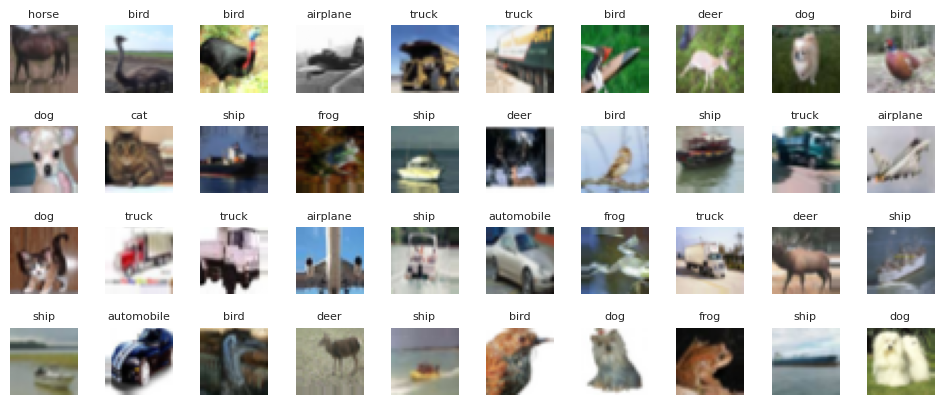

In [17]:
n_rows = 4
n_cols = 10
batch_size = n_rows * n_cols  # 40 images

# Generate one batch of augmented images
for X_batch, y_batch in datagen.flow(X_train, y_train, batch_size=batch_size):
    plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))

    for i in range(batch_size):
        plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow((X_batch[i] + 1) / 2)  # Already in [0,1]
        plt.axis("off")

        # Show class label
        label_idx = int(y_batch[i][0])  # y_batch is (batch, 1)
        plt.title(class_names[label_idx], fontsize=8)

    plt.subplots_adjust(wspace=0.3, hspace=0.5)
    plt.show()
    break  # Only show one batch

In [18]:
from keras import regularizers

In [19]:
# RESNET 32

In [20]:
def resnet_block(inputs, filters, strides, downsample=False):
    shortcut = inputs
    x = keras.layers.Conv2D(filters, kernel_size=3, strides=strides, padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(inputs)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.ReLU()(x)

    x = keras.layers.Conv2D(filters, kernel_size=3, strides=1, padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = keras.layers.BatchNormalization()(x)

    if downsample:
        shortcut = keras.layers.Conv2D(filters, kernel_size=1, strides=strides,
                                 kernel_regularizer=regularizers.l2(1e-4))(shortcut)
        shortcut = keras.layers.BatchNormalization()(shortcut)

    x = keras.layers.add([x, shortcut])
    x = keras.layers.ReLU()(x)
    return x

def build_resnet32(input_shape=(32,32,3), total_classes=10):
    inputs = keras.layers.Input(shape=input_shape)
    x = keras.layers.Conv2D(16, kernel_size=3, strides=1, padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(inputs)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.ReLU()(x)

    # 3 stages of residual blocks (ResNet-32 has 5 blocks per stage)
    for stage, filters in enumerate([16, 32, 64]):
        for block in range(5):
            strides = 1
            downsample = False
            if block == 0 and stage != 0:
                strides = 2
                downsample = True
            x = resnet_block(x, filters, strides, downsample)

    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dense(total_classes, activation='softmax',
                     kernel_regularizer=regularizers.l2(1e-4))(x)

    return keras.models.Model(inputs=inputs, outputs=x)


In [21]:
model = build_resnet32()
# model.summary()

In [22]:
SGD = keras.optimizers.SGD(learning_rate=0.1, momentum=0.9, nesterov=True)

In [23]:
model.compile(optimizer=SGD, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [24]:
def lr_schedule(epoch):
  if epoch < 70:
    return 0.1
  elif epoch < 130:
    return 0.01
  else:
    return 0.001


In [25]:
# early_stopping_cb = keras.callbacks.EarlyStopping(patience=5,
#                                                   monitor="val_loss",
#                                                   restore_best_weights=True)
chk_pt = keras.callbacks.ModelCheckpoint("ResNet32.keras",
                                         save_best_only=True,
                                         monitor="val_loss")

lr_scheduler_cb = keras.callbacks.LearningRateScheduler(lr_schedule)

In [26]:
callbacks = [chk_pt, lr_scheduler_cb]

In [27]:
history = model.fit(datagen.flow(X_train, y_train),
                    batch_size = 128,
                    validation_data=(X_val, y_val),
                    epochs=200,
                    callbacks=callbacks)


Epoch 1/200
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 70s 35ms/step - accuracy: 0.3225 - loss: 2.0300 - val_accuracy: 0.3369 - val_loss: 2.1031 - learning_rate: 0.1000
Epoch 2/200
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 36s 28ms/step - accuracy: 0.5149 - loss: 1.5229 - val_accuracy: 0.5472 - val_loss: 1.5052 - learning_rate: 0.1000
Epoch 3/200
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 36s 28ms/step - accuracy: 0.6316 - loss: 1.2361 - val_accuracy: 0.5887 - val_loss: 1.5557 - learning_rate: 0.1000
Epoch 4/200
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 37s 30ms/step - accuracy: 0.6960 - loss: 1.0924 - val_accuracy: 0.5891 - val_loss: 1.5037 - learning_rate: 0.1000
Epoch 5/200
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 36s 29ms/step - accuracy: 0.7314 - loss: 1.0084 - val_accuracy: 0.4844 - val_loss: 2.5198 - learning_rate: 0.1000
Epoch 6/200
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 36s 29ms/step - accuracy: 0.7517 - loss: 0.9665 - val_accuracy: 0.7148 - val_loss: 1.1422 - learning_rate: 0.1000
Epoch 7/200
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 35s 28ms/step -

## Computer Vision

In [28]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [29]:
!pip install ultralytics==8.3.225

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 30.5 MB/s eta 0:00:00


In [30]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.225 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.2/112.6 GB disk)


In [39]:
# Object Tracking
# path = "/content/cars.mp4"
path = "/content/cars.mp4"

In [40]:
from ultralytics import YOLO
import cv2

In [41]:
model = YOLO("yolov8n.pt")

In [42]:
cap = cv2.VideoCapture(path)
assert cap.isOpened(), "Error reading video file"

In [43]:
w, h, fps = (int(cap.get(x)) for x in (cv2.CAP_PROP_FRAME_WIDTH,
                                       cv2.CAP_PROP_FRAME_HEIGHT,
                                       cv2.CAP_PROP_FPS))

In [44]:
#Create a videowriter object to save the output video with object Tracking
video_write = cv2.VideoWriter("object_tracking.avi",
                              cv2.VideoWriter_fourcc(*"mp4v"),
                              fps, (w,h))

In [45]:
# Loop through each frames
while cap.isOpened():
  success, frame = cap.read()
  # Check if frame is successfully read
  if not success:
    print("Video frame is empty or video processing has been successfully completed")
    break

  #Object tracking
  tracks = model.track(frame, persist=True, tracker="bytetrack.yaml") # default: BoT-SORT

  annotated_frame = tracks[0].plot()

  video_write.write(annotated_frame)


cap.release()
video_write.release()

requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...

requirements: AutoUpdate success ✅ 0.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


0: 384x640 2 cars, 1 truck, 48.8ms
Speed: 11.7ms preprocess, 48.8ms inference, 5.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 12.8ms
Speed: 5.3ms preprocess, 12.8ms inference, 4.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 1 bus, 1 truck, 7.2ms
Speed: 2.7ms preprocess, 7.2ms inference, 2.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 6.6ms
Speed: 2.1ms preprocess, 6.6ms inference, 2.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 1 bus, 1 truck, 8.0ms
Speed: 2.2ms preprocess, 8.0ms inference, 3.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 1 car, 2 trucks, 7.2ms
Speed: 2.1ms preprocess, 7.2ms inference, 3.9ms postprocess per im

In [46]:
!ffmpeg -i /content/object_tracking.avi -vcodec libx264 /content/object_tracking.mp4 -y

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [47]:
from IPython.display import Video

Video("/content/object_tracking.mp4")

In [48]:
from google.colab import files
files.download('/content/object_tracking.mp4')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>